In [1]:
# Cell 1: Setup
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
import torch

sys.path.append(os.path.abspath(os.path.join('..')))

from load_dataset import load_ptbxl_dataset
from run import (
    run_closed_set_identification, 
    run_subject_disjoint_identification,
    run_verification,
    run_subject_disjoint_verification,
    run_cross_session_identification,
    run_cross_session_verification
)
from models import DeepECG, ResNet1D

import warnings
warnings.filterwarnings("ignore")

print("Framework loaded.")
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Running on: {device}")

Framework loaded.
Running on: cpu


In [2]:
print("\n=== TASKS 1-3: Random Split (Baseline) ===")
print("Loading PTB-XL (All Data) for Random Split...")

# 'all' subset includes everyone, maximizing data size
loader = load_ptbxl_dataset(num_beats=3, filter_subset='all', limit_records=500,cleanup_zip=False)
x_all, y_all = loader.load_all_sessions()

print(f"Data Loaded: {x_all.shape} samples, {len(np.unique(y_all))} subjects")

# Run Standard Benchmarks
print("\n[Task 1] Closed-Set Identification")
run_closed_set_identification(x_all, y_all, DeepECG, epochs=2, device=device)

print("\n[Task 2] Verification")
run_verification(x_all, y_all, DeepECG, epochs=2, device=device)

print("\n[Task 3] Subject-Disjoint Verification")
run_subject_disjoint_verification(x_all, y_all, DeepECG, epochs=2, device=device)


=== TASKS 1-3: Random Split (Baseline) ===
Loading PTB-XL (All Data) for Random Split...


Processing signals: 100%|██████████| 500/500 [01:39<00:00,  5.03it/s]


Data Loaded: (5429, 300) samples, 500 subjects

[Task 1] Closed-Set Identification

[TASK] Closed-Set Identification on cpu
    Epoch 001 | Loss: 6.1221
    Epoch 002 | Loss: 5.6800
[RESULT] Closed-Set Accuracy: 0.0378

[Task 2] Verification

[TASK] Verification (Random Split / Closed-Set) on cpu
[INFO] Phase 1: Training feature extractor (Learning Identity)...
    Epoch 001 | Loss: 6.1561
    Epoch 002 | Loss: 5.7770
[INFO] Phase 2: Computing EER using 'balanced' sampling...
[INFO] Generating 10000 BALANCED pairs (50/50 split)...
[RESULT] Mode: BALANCED | EER: 0.1734 | AUC: 0.9083

[Task 3] Subject-Disjoint Verification

[TASK] Subject-Disjoint Verification (Open-Set) on cpu
[INFO] Splitting: 350 Training Subjects vs 150 Test Subjects
[INFO] Phase 1: Training on Known Subjects...
    Epoch 001 | Loss: 5.7378
    Epoch 002 | Loss: 5.3291
[INFO] Phase 2: Computing EER on 150 Unseen Subjects...
[INFO] Generating 10000 BALANCED pairs (50/50 split)...
[RESULT] Mode: BALANCED | EER: 0.1644 

{'eer': 0.16439999999999347, 'auc': 0.9197909400000001}


=== TASK 4: Biometric Regimes ===

[A] Loading Short-Term Regime (Intra-Record 50/50)...


Processing Session_2: 100%|██████████| 500/500 [00:42<00:00, 11.89it/s]


    Short-Term Shapes: Enroll (2581, 300), Probe (2848, 300)
    Running Verification...

[TASK] Cross-Session Verification (EER) on cpu
[INFO] Phase 1: Training Feature Extractor on Session 1...
    Epoch 001 | Loss: 6.1911
    Epoch 002 | Loss: 5.9614
[INFO] Phase 2: Extracting Embeddings for Pairing...
[INFO] Generating 10000 Cross-Session Pairs (balanced)...
[RESULT] Cross-Session EER: 0.2124 | AUC: 0.8751

[B] Loading Long-Term Regime (First Rec vs Future Recs)...


Processing Session_2: 100%|██████████| 500/500 [00:04<00:00, 111.79it/s]


    Long-Term Shapes: Enroll (414, 300), Probe (604, 300)
    Running Verification...

[TASK] Cross-Session Verification (EER) on cpu
[INFO] Phase 1: Training Feature Extractor on Session 1...
    Epoch 001 | Loss: 3.6818
    Epoch 002 | Loss: 3.6310
    Epoch 003 | Loss: 3.5732
    Epoch 004 | Loss: 3.4969
    Epoch 005 | Loss: 3.3993
    Epoch 006 | Loss: 3.2923
    Epoch 007 | Loss: 3.1775
    Epoch 008 | Loss: 3.0800
    Epoch 009 | Loss: 2.9636
    Epoch 010 | Loss: 2.8516
    Epoch 011 | Loss: 2.7405
    Epoch 012 | Loss: 2.6415
    Epoch 013 | Loss: 2.5252
    Epoch 014 | Loss: 2.4154
    Epoch 015 | Loss: 2.2938
[INFO] Phase 2: Extracting Embeddings for Pairing...
[INFO] Generating 10000 Cross-Session Pairs (balanced)...
[RESULT] Cross-Session EER: 0.1922 | AUC: 0.8900
[INFO] Computing T-SNE... this may take a moment.


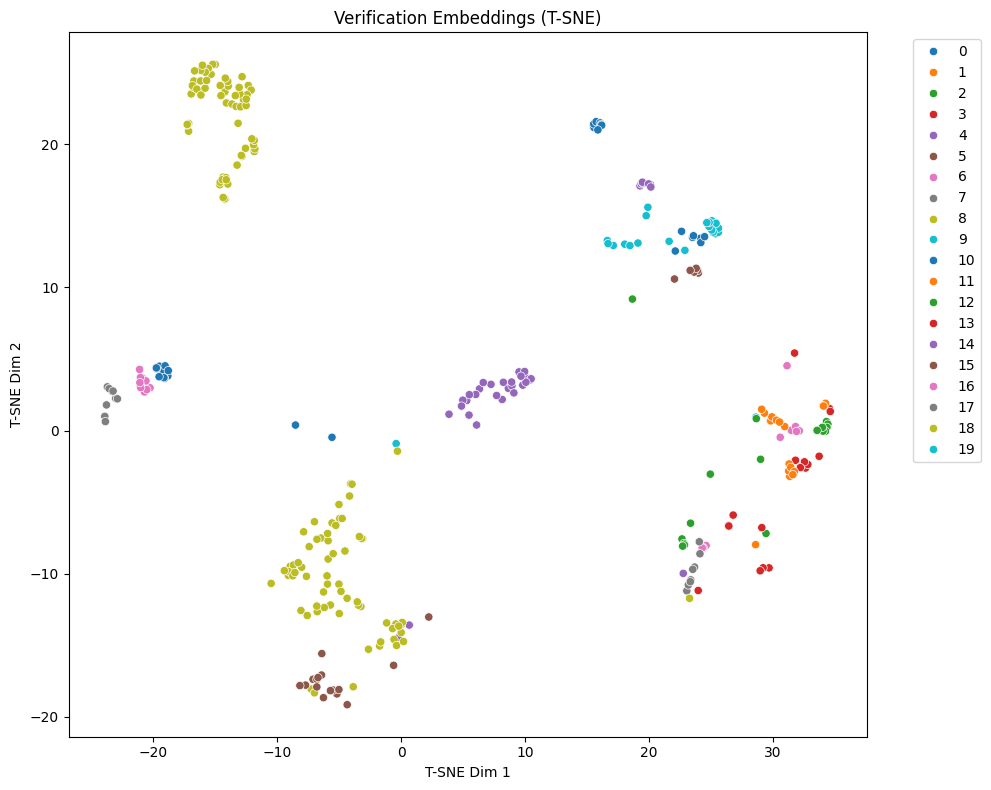

{'eer': 0.19220000000020307, 'auc': 0.8899906}

In [3]:
print("\n=== TASK 4: Biometric Regimes ===")

# A. SHORT-TERM (Row 1)
# Description: Intra-Record 50/50 Split (0-5s vs 5-10s).
# Why: Allows us to benchmark ALL subjects (even single-record ones) on immediate stability.
print("\n[A] Loading Short-Term Regime (Intra-Record 50/50)...")
loader_st = load_ptbxl_dataset(
    num_beats=3, 
    filter_subset='all',
    limit_records=500,
    cleanup_zip=False
)
x_st_enr, y_st_enr = loader_st.load_session("Session_1", split_mode="short_term")
x_st_prb, y_st_prb = loader_st.load_session("Session_2", split_mode="short_term")
print(f"    Short-Term Shapes: Enroll {x_st_enr.shape}, Probe {x_st_prb.shape}")

print("    Running Verification...")
run_cross_session_verification(x_st_enr, y_st_enr, x_st_prb, y_st_prb, DeepECG, epochs=2, device=device, visualize=False)


# B. LONG-TERM (Row 2)
# Description: Inter-Record Split (Rec 1 vs Rec 2+).
# Why: The true biometric test. Uses only subjects with multiple visits.
print("\n[B] Loading Long-Term Regime (First Rec vs Future Recs)...")
loader_lt = load_ptbxl_dataset(
    num_beats=3, 
    filter_subset='all', # Loader filters internally based on count
    limit_records=500,
    cleanup_zip=False
)
x_lt_enr, y_lt_enr = loader_lt.load_session("Session_1", split_mode="long_term")
x_lt_prb, y_lt_prb = loader_lt.load_session("Session_2", split_mode="long_term")
print(f"    Long-Term Shapes: Enroll {x_lt_enr.shape}, Probe {x_lt_prb.shape}")

print("    Running Verification...")
run_cross_session_verification(x_lt_enr, y_lt_enr, x_lt_prb, y_lt_prb, DeepECG, epochs=15, device=device, visualize=True)

In [4]:
print("\n=== TASK 5: Blind Segmentation (Long-Term Regime) ===")

blind_params = {
    'mode': 'blind',
    'window_len': 2.0,  
    'stride': 1.0,      
    'bandpass': True,
    'normalize': 'zscore'
}


loader_blind = load_ptbxl_dataset(
    num_beats=1, 
    filter_subset='all',
    preprocessing_params=blind_params, 
    limit_records=5000,
    cleanup_zip=False
)

x_blind_enr, y_blind_enr = loader_blind.load_session("Session_1", split_mode="long_term")
x_blind_prb, y_blind_prb = loader_blind.load_session("Session_2", split_mode="long_term")
print(f"Blind Data Shapes: Enroll {x_blind_enr.shape}, Probe {x_blind_prb.shape}")

print("\n[Blind] Identification")
run_cross_session_identification(x_blind_enr, y_blind_enr, x_blind_prb, y_blind_prb, DeepECG, epochs=2, device=device)

print("\n[Blind] Verification")
run_cross_session_verification(x_blind_enr, y_blind_enr, x_blind_prb, y_blind_prb, DeepECG, epochs=2, device=device)


=== TASK 5: Blind Segmentation (Long-Term Regime) ===


Processing Session_2: 100%|██████████| 5000/5000 [00:00<00:00, 10819.34it/s]


Blind Data Shapes: Enroll (3897, 1000), Probe (5355, 1000)

[Blind] Identification

[TASK] Cross-Session Identification (Rank-1) on cpu
[INFO] Subjects: 433 in Train, 433 in Test.
[INFO] Evaluated on intersection: 433 common subjects.
[INFO] Phase 1: Training Classifier on Session 1...
    Epoch 001 | Loss: 6.0521
    Epoch 002 | Loss: 5.6479
[INFO] Phase 2: Predicting on Session 2...
[RESULT] Cross-Session Identification Accuracy: 0.65%

[Blind] Verification

[TASK] Cross-Session Verification (EER) on cpu
[INFO] Phase 1: Training Feature Extractor on Session 1...
    Epoch 001 | Loss: 6.0521
    Epoch 002 | Loss: 5.6479
[INFO] Phase 2: Extracting Embeddings for Pairing...
[INFO] Generating 10000 Cross-Session Pairs (balanced)...
[RESULT] Cross-Session EER: 0.2818 | AUC: 0.7938


{'eer': 0.28180000000035427, 'auc': 0.7938422}